### 00

In [1]:
%matplotlib inline

import numpy as np 
import pandas as pd

import numba
import torch

from pathlib import Path

from matplotlib import pyplot as plt

from scipy import sparse

from threadpoolctl import ThreadpoolController, threadpool_limits

%load_ext cython
import random
import numpy as np
import torch

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # für vollständige Reproduzierbarkeit (optional)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [3]:
CURRENT_WORKING_DIRECTORY = Path.cwd()
CURRENT_WORKING_DIRECTORY

PosixPath('/Users/anasshbat/Desktop/Uni-mac/Winter26/Projeckt_GNN')

In [4]:
from pathlib import Path
csv_path = "/Users/anasshbat/Desktop/Uni-mac/Winter26/ADA/P_GNN_25/GNN_Projekt_ADA_25/main_notebook/data/00_R_tot_for_Grains_and_Rho_Ratio.csv"
grids_folder = Path("/Users/anasshbat/Desktop/Uni-mac/Winter26/ADA/P_GNN_25/GNN_Projekt_ADA_25/main_notebook/data/00_grids")

### 01- Data Laden

In [5]:
import pandas as pd
import numpy as np

# CSV-Daten einlesen
df = pd.read_csv(csv_path, comment='#', header=0)

# Erste Zeile enthält die rho_ratio-Werte
rho_ratios = df.columns[1:].astype(float)

# Leeren DataFrame für alle Daten vorbereiten
all_data = []

# Für jede Grain-Zeile
for idx, row in df.iterrows():
    grain = row['Grains']
    values = row[1:].values
    
    # Für jedes rho_ratio einen Eintrag erstellen
    for rho, val in zip(rho_ratios, values):
        all_data.append({
            'Grains': grain,
            'rho_ratio': rho,
            'R_tot_Ohm': val
        })

# Zu DataFrame konvertieren
df_R = pd.DataFrame(all_data)

df_R.info

# Spalte 'Grains' zu 'grains' umbenennen
df_R = df_R.rename(columns={"Grains": "grains", "rho_ratio": "leitfaehigkeit", "R_tot_Ohm": "widerstand"})

# Optional: prüfen
print(df_R.head())


   grains  leitfaehigkeit    widerstand
0    16.0            1.00  10000.233814
1    16.0            1.26  10000.295718
2    16.0            1.60  10000.373979
3    16.0            2.02  10000.472937
4    16.0            2.56  10000.598052


In [6]:
import pandas as pd
import numpy as np


targets = [10**2, 10**3, 10**4, 10**5]

def messung_von_leitfaehigkeit_(df, target_list):
    """
    Findet die Zeilen im DataFrame, deren 'leitfaehigkeit' am nächsten an den Zielwerten liegt.
    
    Parameter:
    df (pd.DataFrame): Der Quelldatensatz.
    target_list (list): Liste der gewünschten Leitfähigkeits-Zielwerte.
    
    Rückgabe:
    pd.DataFrame: Gefilterter DataFrame mit den am nächsten liegenden Messwerten.
    """
    if df.empty:
        return df

    # Alle einzigartigen Leitfähigkeitswerte extrahieren
    unique_conds = df['leitfaehigkeit'].unique()
    selected_values = []
    
    for t in target_list:
        idx = np.abs(unique_conds - t).argmin()
        selected_values.append(unique_conds[idx])
    
    # Filtert den Original-DF auf die gefundenen Best-Matches
    return df[df['leitfaehigkeit'].isin(selected_values)]

# 1. Deine Auswahl der Leitfähigkeiten (hast du schon)
df_ml = messung_von_leitfaehigkeit_(df_R, targets)

# 2. Max Grain Size festlegen (z.B. 500 oder 1000)
max_grains = 500 

# 3. Den DataFrame zusätzlich filtern
df_ml = df_ml[df_ml['grains'] <= max_grains].copy()

# 4. Log-Werte berechnen
df_ml['u_log'] = np.log10(df_ml['leitfaehigkeit'])
df_ml['y_log'] = np.log10(df_ml['widerstand'])

print(f"Dataset bereit mit {len(df_ml)} Graphen.")
print(f"Grains von {df_ml['grains'].min()} bis {df_ml['grains'].max()}")


Dataset bereit mit 600 Graphen.
Grains von 16.0 bis 500.0


In [7]:
import re

grain_to_file_map = {}

# Wir suchen nur nach .npz Dateien
for f in grids_folder.glob("*.npz"):
    # Wir extrahieren die Zahl nach 'grains_'
    match = re.search(r'grains_(\d+)', f.name)
    if match:
        num = int(match.group(1))
        # Wir speichern den Pfad für diese Grain-Anzahl
        grain_to_file_map[num] = f

print(f"Erfolg! {len(grain_to_file_map)} Geometrien im Mapping registriert.")
print(f"Beispiel: Grains 788 -> {grain_to_file_map.get(788)}")

Erfolg! 930 Geometrien im Mapping registriert.
Beispiel: Grains 788 -> /Users/anasshbat/Desktop/Uni-mac/Winter26/ADA/P_GNN_25/GNN_Projekt_ADA_25/main_notebook/data/00_grids/00263_grid_101x101x101__grains_788.npz


### Mapping der Geometrien zu den Daten

In [8]:
import torch
import numpy as np
from torch_geometric.data import Data, Dataset
from gnn_tools.preprocessing import GrainsToGraph

In [9]:
class SparseGrainDataset(Dataset):
    def __init__(self, df_ml, grain_mapping):
        super().__init__()
        self.df_ml = df_ml
        self.grain_mapping = grain_mapping
        self.cache = {} 

    def len(self):
        return len(self.df_ml)

    def __len__(self):
        return self.len()

    def get(self, idx):
        row = self.df_ml.iloc[idx]
        grain_count = int(row['grains'])
        file_path = self.grain_mapping[grain_count]

        if file_path not in self.cache:
            g2g = GrainsToGraph(filepath=file_path)
            node_info = g2g.node_information(as_frame=True)
            
            # Nur Geometrie-Daten (4 Features: Vol, X, Y, Z)
            geom = node_info[['volume', 'center-coord-0', 'center-coord-1', 'center-coord-2']].values.copy()
            
            # Normalisierung (wie bisher)
            vol_max = geom[:, 0].max()
            if vol_max > 0: geom[:, 0] /= vol_max
            for i in range(1, 4):
                c_min, c_max = geom[:, i].min(), geom[:, i].max()
                if (c_max - c_min) > 0:
                    geom[:, i] = (geom[:, i] - c_min) / (c_max - c_min)
            
            edge_info = g2g.edge_information(as_frame=True)
            edge_index = torch.tensor(edge_info[['center_node', 'neighbor_node']].values.T, dtype=torch.long)
            
            # Kanten-Features (optional für das Modell nutzbar)
            edge_attr = torch.tensor(edge_info[['contact_area', 'distance']].values, dtype=torch.float)
            
            self.cache[file_path] = (geom, edge_index, edge_attr)
        
        geom_cached, edge_index, edge_attr = self.cache[file_path]
        
        # Knoten-Features (x) enthalten jetzt NUR die Geometrie (4 Spalten)
        x = torch.tensor(geom_cached, dtype=torch.float)
        
        # Globaler Parameter u (Leitfähigkeit)
        u = torch.tensor([row['u_log']], dtype=torch.float)
        
        # Target (Widerstand)
        y = torch.tensor([row['y_log']], dtype=torch.float)

        # Wir fügen 'u' als zusätzliches Attribut zum Data-Objekt hinzu
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, u=u)

### Baseline GNN Modell

In [10]:
if 'device' not in locals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import BatchNorm, NNConv, global_mean_pool

class GrainGNN(nn.Module):
    def __init__(self, node_features=4, edge_features=2, h_fea_len=128):
        super().__init__()

        edge_nn1 = nn.Sequential(
            nn.Linear(edge_features, 64),
            nn.ReLU(),
            nn.Linear(64, node_features * 64)
        )

        edge_nn2 = nn.Sequential(
            nn.Linear(edge_features, 64),
            nn.ReLU(),
            nn.Linear(64, 64 * 64)
        )

        self.conv1 = NNConv(node_features, 64, edge_nn1)
        self.bn1 = BatchNorm(64)

        self.conv2 = NNConv(64, 64, edge_nn2)
        self.bn2 = BatchNorm(64)

        self.fc = nn.Sequential(
            nn.Linear(64 + 1, h_fea_len),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(h_fea_len, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x, data.edge_index, data.edge_attr, data.batch, data.u
        )

        x1 = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x2 = F.relu(self.bn2(self.conv2(x1, edge_index, edge_attr)))

        x = x1 + x2  # residual

        x_pool = global_mean_pool(x, batch)

        if u.dim() == 1:
            u = u.view(-1, 1)

        x = torch.cat([x_pool, u], dim=1)
        return self.fc(x)

In [13]:
'''from torch_geometric.nn import BatchNorm, GATv2Conv

class GrainGNN(nn.Module):
    def __init__(self, node_features=4, edge_features=2, h_fea_len=128):
        super(GrainGNN, self).__init__()
        
        # GATv2 ist schneller als NNConv und nutzt Edge-Features
        self.conv1 = GATv2Conv(node_features, 64, edge_dim=edge_features)
        self.bn1 = BatchNorm(64)
        self.conv2 = GATv2Conv(64, 64, edge_dim=edge_features)
        self.bn2 = BatchNorm(64)
        
        self.fc = nn.Sequential(
            nn.Linear(64 + 1, h_fea_len),
            nn.ReLU(),
            nn.Dropout(0.2), # Verhindert Overfitting
            nn.Linear(h_fea_len, 1) 
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = data.x, data.edge_index, data.edge_attr, data.batch, data.u
        
        # Graph Teil mit Normalisierung
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        
        x_pool = global_mean_pool(x, batch) 
        
        if u.dim() == 1: u = u.view(-1, 1)
        # WICHTIG: u sollte hier idealerweise auch log-skaliert sein!
        combined = torch.cat([x_pool, u], dim=1)
        
        return self.fc(combined)'''


'from torch_geometric.nn import BatchNorm, GATv2Conv\n\nclass GrainGNN(nn.Module):\n    def __init__(self, node_features=4, edge_features=2, h_fea_len=128):\n        super(GrainGNN, self).__init__()\n\n        # GATv2 ist schneller als NNConv und nutzt Edge-Features\n        self.conv1 = GATv2Conv(node_features, 64, edge_dim=edge_features)\n        self.bn1 = BatchNorm(64)\n        self.conv2 = GATv2Conv(64, 64, edge_dim=edge_features)\n        self.bn2 = BatchNorm(64)\n\n        self.fc = nn.Sequential(\n            nn.Linear(64 + 1, h_fea_len),\n            nn.ReLU(),\n            nn.Dropout(0.2), # Verhindert Overfitting\n            nn.Linear(h_fea_len, 1) \n        )\n\n    def forward(self, data):\n        x, edge_index, edge_attr, batch, u = data.x, data.edge_index, data.edge_attr, data.batch, data.u\n\n        # Graph Teil mit Normalisierung\n        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))\n        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))\n\

In [14]:
def train_with_history(model, train_loader, val_loader, optimizer, criterion, epochs=50):
    
    history = {'train': [], 'val': []}
    
    for epoch in range(epochs):
        
        # ================= TRAIN =================
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            batch = batch.to(device)
            
            optimizer.zero_grad()
            
            out = model(batch)
            loss = criterion(out, batch.y.view(-1, 1))
            
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item() * batch.num_graphs

        # ================= VALIDATION =================
        model.eval()
        total_val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                
                out = model(batch)
                val_loss = criterion(out, batch.y.view(-1, 1))
                
                total_val_loss += val_loss.item() * batch.num_graphs

        # ================= METRICS =================
        train_loss = total_train_loss / len(train_loader.dataset)
        val_loss = total_val_loss / len(val_loader.dataset)
        
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch:03d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
            
    return history


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt


def analyze_model_performance(model, loader, history=None, device="cpu"):
    
    model.eval()
    
    preds_log = []
    actuals_log = []
    
    # ================= PREDICTIONS SAMMELN =================
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            
            preds_log.extend(out.cpu().numpy().flatten())
            actuals_log.extend(batch.y.cpu().numpy().flatten())
    
    preds_log = np.array(preds_log)
    actuals_log = np.array(actuals_log)
    
    # ================= REAL SPACE =================
    preds_real = 10 ** preds_log
    actuals_real = 10 ** actuals_log
    
    # ================= METRICS LOG SPACE =================
    mae_log = mean_absolute_error(actuals_log, preds_log)
    
    mape_log = np.mean(np.abs((actuals_log - preds_log) / actuals_log)) * 100
    max_mape_log = np.max(np.abs((actuals_log - preds_log) / actuals_log)) * 100
    
    r2_log = r2_score(actuals_log, preds_log)
    
    # ================= METRICS REAL SPACE =================
    mae_real = mean_absolute_error(actuals_real, preds_real)
    
    mape_real = np.mean(np.abs((actuals_real - preds_real) / actuals_real)) * 100
    max_mape_real = np.max(np.abs((actuals_real - preds_real) / actuals_real)) * 100
    
    r2_real = r2_score(actuals_real, preds_real)
    
    # ================= PRINT METRICS =================
    print("\n===== LOG SPACE METRICS =====")
    print(f"MAE Log      : {mae_log:.6f}")
    print(f"MAPE Log (%) : {mape_log:.4f}")
    print(f"MAX MAPE Log : {max_mape_log:.4f}")
    print(f"R² Log       : {r2_log:.6f}")
    
    print("\n===== REAL SPACE METRICS =====")
    print(f"MAE Real      : {mae_real:.6f}")
    print(f"MAPE Real (%) : {mape_real:.4f}")
    print(f"MAX MAPE Real : {max_mape_real:.4f}")
    print(f"R² Real       : {r2_real:.6f}")
    
    # ================= LOSS PLOT =================
    if history is not None:
        plt.figure(figsize=(8,5))
        plt.plot(history['train'], label="Train Loss")
        plt.plot(history['val'], label="Val Loss")
        plt.yscale("log")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title("Training History")
        plt.legend()
        plt.grid()
        plt.show()
    
    # ================= PARITY LOG =================
    plt.figure(figsize=(6,6))
    plt.scatter(actuals_log, preds_log, alpha=0.5)
    
    min_v = min(actuals_log.min(), preds_log.min())
    max_v = max(actuals_log.max(), preds_log.max())
    
    plt.plot([min_v, max_v], [min_v, max_v], "--")
    plt.xlabel("True Log10(R)")
    plt.ylabel("Pred Log10(R)")
    plt.title("Parity Plot (Log Space)")
    plt.grid()
    plt.show()
    
    # ================= PARITY REAL =================
    plt.figure(figsize=(6,6))
    plt.scatter(actuals_real, preds_real, alpha=0.5)
    
    min_v = min(actuals_real.min(), preds_real.min())
    max_v = max(actuals_real.max(), preds_real.max())
    
    plt.plot([min_v, max_v], [min_v, max_v], "--")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("True R")
    plt.ylabel("Pred R")
    plt.title("Parity Plot (Real Space)")
    plt.grid()
    plt.show()
    
    return {
        "mae_log": mae_log,
        "mape_log": mape_log,
        "max_mape_log": max_mape_log,
        "r2_log": r2_log,
        "mae_real": mae_real,
        "mape_real": mape_real,
        "max_mape_real": max_mape_real,
        "r2_real": r2_real
    }


In [16]:
def predict_on_loader(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            y_true.append(batch.y.cpu())
            y_pred.append(out.cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return y_true, y_pred

def plot_true_vs_pred(y_true, y_pred, title="True vs Predicted"):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(title)
    plt.grid(True)
    plt.show()

### Experimentelle Trainingsschleife

In [17]:
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    # Training
    epochs: int = 50
    batch_size: int = 32
    lr: float = 1e-3
    
    # Model
    node_features: int = 4
    hidden_dim: int = 128
    edge_features: int = 2
    
    # Dataset
    max_grains: int = 500
    targets: tuple = (1e2, 1e3, 1e4, 1e5)
    
    # Seed
    seed: int = 42
    
    # Logging
    experiment_name: str = "baseline_gnn"


In [18]:
def setup_experiment(cfg: ExperimentConfig):
    print(f"\n===== Experiment: {cfg.experiment_name} =====")
    
    seed_everything(cfg.seed)
    
    model = GrainGNN(
        node_features=cfg.node_features,
        edge_features=cfg.edge_features,
        h_fea_len=cfg.hidden_dim
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.MSELoss()
    
    return model, optimizer, criterion


In [19]:
import os
import json

def get_exp_folder(cfg: ExperimentConfig):
    base_dir = "./exps"
    exp_dir = os.path.join(base_dir, cfg.experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    return exp_dir

In [20]:
def messung_von_leitfaehigkeit_(df, target_list):
    """
    Findet die Zeilen im DataFrame, deren 'leitfaehigkeit' am nächsten an den Zielwerten liegt.
    
    Parameter:
    df (pd.DataFrame): Der Quelldatensatz.
    target_list (list): Liste der gewünschten Leitfähigkeits-Zielwerte.
    
    Rückgabe:
    pd.DataFrame: Gefilterter DataFrame mit den am nächsten liegenden Messwerten.
    """
    if df.empty:
        return df

    # Alle einzigartigen Leitfähigkeitswerte extrahieren
    unique_conds = df['leitfaehigkeit'].unique()
    selected_values = []
    
    for t in target_list:
        idx = np.abs(unique_conds - t).argmin()
        selected_values.append(unique_conds[idx])
    
    # Filtert den Original-DF auf die gefundenen Best-Matches
    return df[df['leitfaehigkeit'].isin(selected_values)]

In [21]:
def build_dataset(cfg: ExperimentConfig):
    df_ml_local = df_R.copy()
   # df_ml_local = messung_von_leitfaehigkeit_(df_R, cfg.targets)
    df_ml_local = df_ml_local[df_ml_local['grains'] <= cfg.max_grains].copy()
    
    df_ml_local['u_log'] = np.log10(df_ml_local['leitfaehigkeit'])
    df_ml_local['y_log'] = np.log10(df_ml_local['widerstand'])
    
    dataset_local = SparseGrainDataset(df_ml_local, grain_to_file_map)
    print(f"Dataset enthält {len(df_ml_local)} Graphen.")
    print(f"Leitfähigkeiten: {sorted(df_ml_local['leitfaehigkeit'].unique())}")
    return dataset_local


In [22]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split 
def build_loaders(dataset, cfg: ExperimentConfig):
    n_total = len(dataset)
    train_size = int(0.8 * n_total)
    val_size = n_total - train_size
    
    # Reproduzierbarer Split mit Seed (80/20)
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(cfg.seed)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
    
    # Test-Loader = Val-Loader für Kompatibilität
    test_loader = val_loader
    
    return train_loader, val_loader, test_loader


In [21]:
''' # Import random_split

def build_loaders(dataset, cfg: ExperimentConfig):
    
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.batch_size,
        shuffle=False
    )
    
    return train_loader, val_loader'''


' # Import random_split\n\ndef build_loaders(dataset, cfg: ExperimentConfig):\n\n    train_size = int(0.8 * len(dataset))\n    val_size = len(dataset) - train_size\n\n    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])\n\n    train_loader = DataLoader(\n        train_dataset,\n        batch_size=cfg.batch_size,\n        shuffle=True\n    )\n\n    val_loader = DataLoader(\n        val_dataset,\n        batch_size=cfg.batch_size,\n        shuffle=False\n    )\n\n    return train_loader, val_loader'

In [23]:
def main_train(cfg: ExperimentConfig):
    
    # 1️⃣ Setup
    model, optimizer, criterion = setup_experiment(cfg)
    
    # 2️⃣ Dataset & Loader
    dataset = build_dataset(cfg)
    train_loader, val_loader, test_loader = build_loaders(dataset, cfg)
    
    # 3️⃣ Training
    history = train_with_history(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=cfg.epochs
    )
    
    # 4️⃣ Ordner für Experiment erstellen
    exp_dir = get_exp_folder(cfg)
    
    # 5️⃣ Konfiguration speichern
    cfg_path = os.path.join(exp_dir, "config.json")
    with open(cfg_path, "w") as f:
        json.dump(cfg.__dict__, f, indent=4)
    
    # 6️⃣ Modell speichern
    model_path = os.path.join(exp_dir, "best_model.pth")
    torch.save(model.state_dict(), model_path)
    
    # 7️⃣ Trainingshistorie speichern
    history_path = os.path.join(exp_dir, "training_history.csv")
    import pandas as pd
    pd.DataFrame(history).to_csv(history_path, index=False)
    
    print(f"Experiment '{cfg.experiment_name}' gespeichert in {exp_dir}")
    
    return model, history


In [26]:
cfg = ExperimentConfig(
    epochs=200,
    batch_size=32,
    lr=1e-3,
    hidden_dim=128,
    
    experiment_name="nnconv_EP50_L62"  #  L= leitfähigkeit , 62 all leitfähigkeit , Ep= Epochs
)

model, history = main_train(cfg)


===== Experiment: nnconv_EP50_L62 =====
Dataset enthält 9300 Graphen.
Leitfähigkeiten: [1.0, 1.26, 1.6, 2.02, 2.56, 3.24, 4.0, 4.09, 5.18, 6.55, 7.0, 8.29, 10.0, 10.5, 13.3, 16.8, 21.2, 26.8, 33.9, 40.0, 42.9, 54.3, 68.7, 70.0, 86.9, 100.0, 110.0, 139.0, 176.0, 222.0, 281.0, 356.0, 400.0, 450.0, 569.0, 700.0, 720.0, 910.0, 1000.0, 1150.0, 1460.0, 1840.0, 2330.0, 2950.0, 3730.0, 4000.0, 4710.0, 5960.0, 7000.0, 7540.0, 9540.0, 10000.0, 12100.0, 15300.0, 19300.0, 24400.0, 30900.0, 39100.0, 49400.0, 62500.0, 79100.0, 100000.0]
Epoch 000 | Train MSE: 0.828396 | Val MSE: 0.030095
Epoch 005 | Train MSE: 0.072697 | Val MSE: 0.009404
Epoch 010 | Train MSE: 0.063521 | Val MSE: 0.017015
Epoch 015 | Train MSE: 0.056955 | Val MSE: 0.005778
Epoch 020 | Train MSE: 0.052838 | Val MSE: 0.006806


KeyboardInterrupt: 


===== LOG SPACE METRICS =====
MAE Log      : 0.174523
MAPE Log (%) : 4.3191
MAX MAPE Log : 16.4236
R² Log       : -1.509570

===== REAL SPACE METRICS =====
MAE Real      : 3839.326904
MAPE Real (%) : 31.8841
MAX MAPE Real : 85.1336
R² Real       : 0.473825


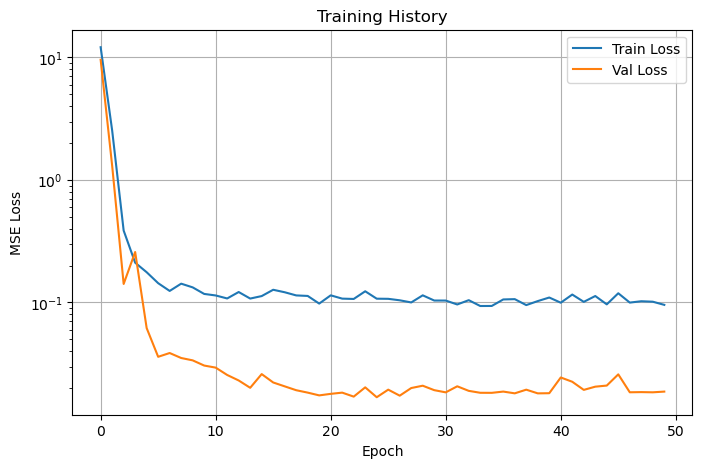

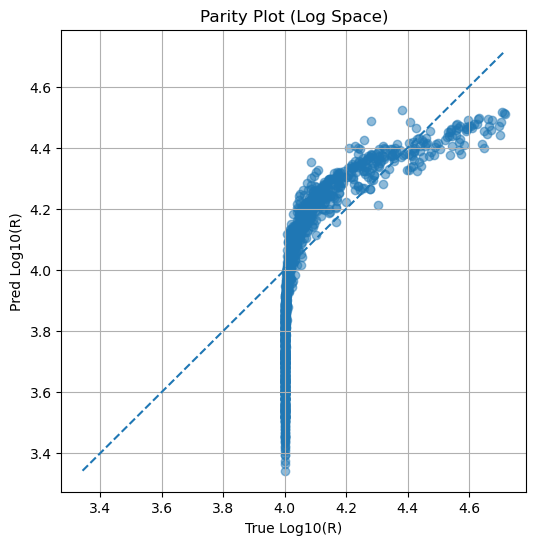

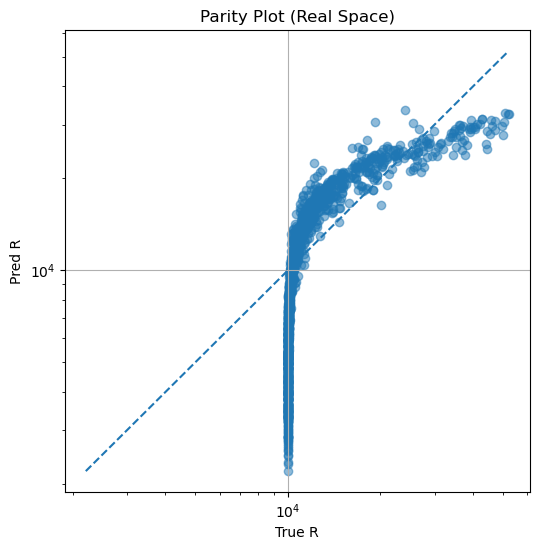

In [33]:
if 'val_loader' not in locals():
	dataset = build_dataset(cfg)
	_, val_loader, test_loader = build_loaders(dataset, cfg)
metrics = analyze_model_performance(model, val_loader, history, device=device)


===== LOG SPACE METRICS =====
MAE Log      : 0.004002
MAPE Log (%) : 0.0961
MAX MAPE Log : 0.9823
R² Log       : 0.998184

===== REAL SPACE METRICS =====
MAE Real      : 155.909592
MAPE Real (%) : 0.9265
MAX MAPE Real : 9.9286
R² Real       : 0.997208


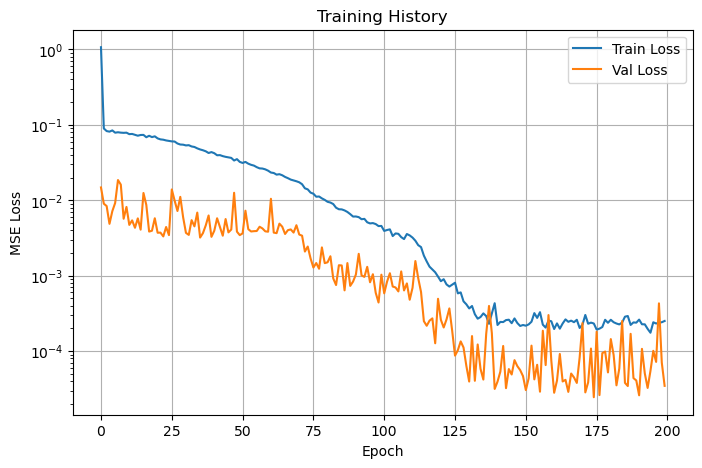

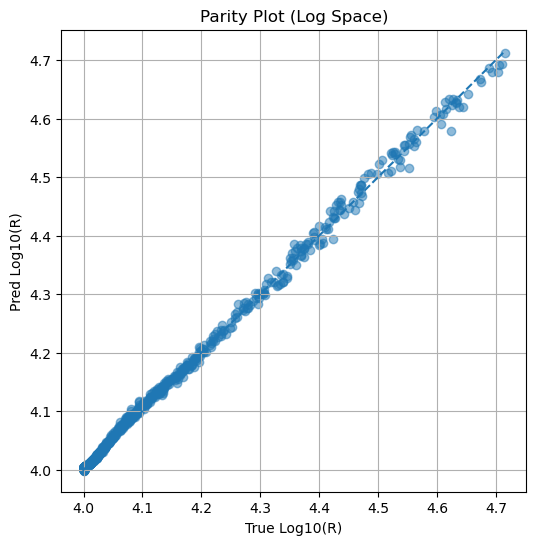

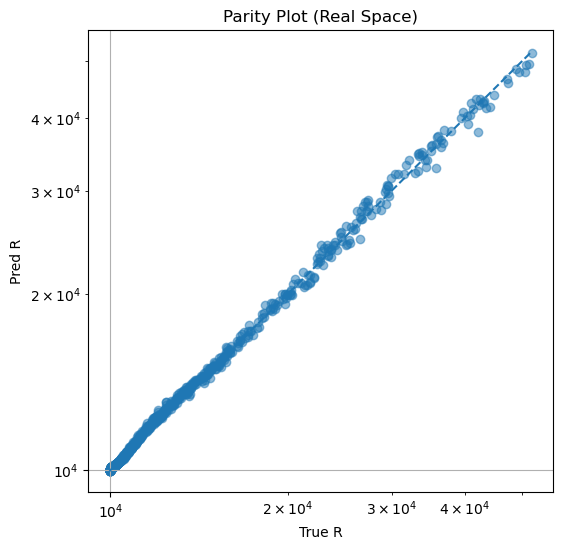

In [59]:
# Ensure test_loader is defined
if 'test_loader' not in locals():
	dataset = build_dataset(cfg)
	_, _, test_loader = build_loaders(dataset, cfg)

metrics = analyze_model_performance(model, test_loader, history, device=device)

In [26]:
exp_path = '/Users/anasshbat/Desktop/Uni-mac/Winter26/Projeckt_GNN/gnn_uni/exps'
listdir = os.listdir(exp_path)
print(listdir)

['exp_model_all_leitfaehigkeit&200_Epoch', '02_baseline_gnn_v2', '.DS_Store', 'exp_model_u_nach_conv', 'exp_optimized_2', 'Test', 'exp_test', 'exp_grain_baseline', 'exp_modelB__G500_ALL_leits', 'exp_model_all_leitfaehigkeit', 'exp_model_v1', 'exp_model_4L_500_50E-4leitfaehigkeit', '01_exp_baseM_200Ep', 'Test_Experiment', 'exp_modelB__G5000_L4', 'exp_modelB__Gg500_4', 'exp_optimized', 'exp_model_4L_Gk2000_50E', 'exp_modelB__G2000_L4', 'exp_model_u_nach_conv_200_epochen']


In [25]:
model.load_state_dict(torch.load(f"{cfg.experiment_name}_model.pth", map_location=device))
model.to(device)


NameError: name 'model' is not defined

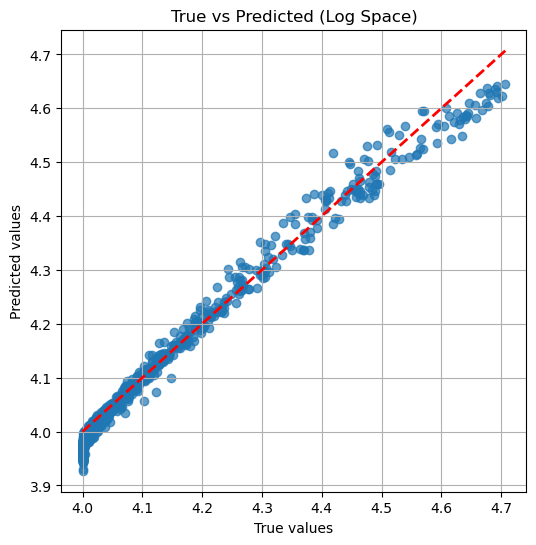

In [27]:
true_log, pred_log = predict_on_loader(model, test_loader, device)
plot_true_vs_pred(true_log, pred_log, title="True vs Predicted (Log Space)")

Checkpoint geladen mit Architektur: GATV2
Dataset enthält 9300 Graphen.
Leitfähigkeiten: [1.0, 1.26, 1.6, 2.02, 2.56, 3.24, 4.0, 4.09, 5.18, 6.55, 7.0, 8.29, 10.0, 10.5, 13.3, 16.8, 21.2, 26.8, 33.9, 40.0, 42.9, 54.3, 68.7, 70.0, 86.9, 100.0, 110.0, 139.0, 176.0, 222.0, 281.0, 356.0, 400.0, 450.0, 569.0, 700.0, 720.0, 910.0, 1000.0, 1150.0, 1460.0, 1840.0, 2330.0, 2950.0, 3730.0, 4000.0, 4710.0, 5960.0, 7000.0, 7540.0, 9540.0, 10000.0, 12100.0, 15300.0, 19300.0, 24400.0, 30900.0, 39100.0, 49400.0, 62500.0, 79100.0, 100000.0]

===== LOG SPACE METRICS =====
MAE Log      : 0.003889
MAPE Log (%) : 0.0935
MAX MAPE Log : 0.7944
R² Log       : 0.998157

===== REAL SPACE METRICS =====
MAE Real      : 149.380417
MAPE Real (%) : 0.9005
MAX MAPE Real : 8.1948
R² Real       : 0.997074


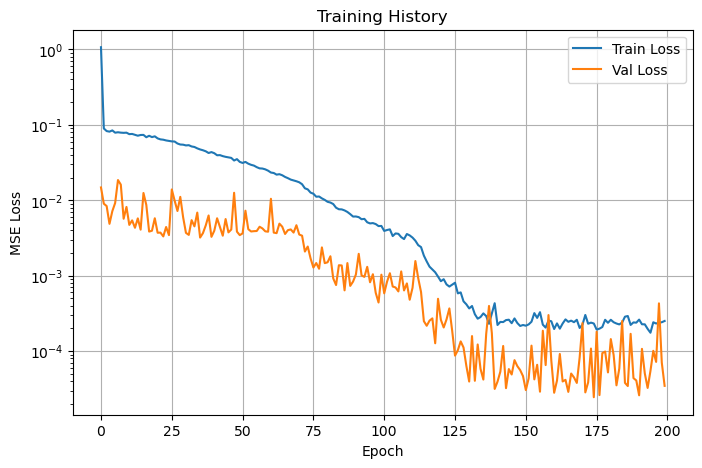

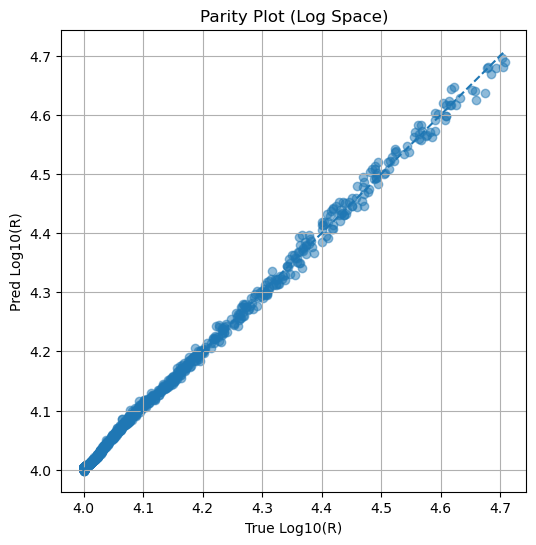

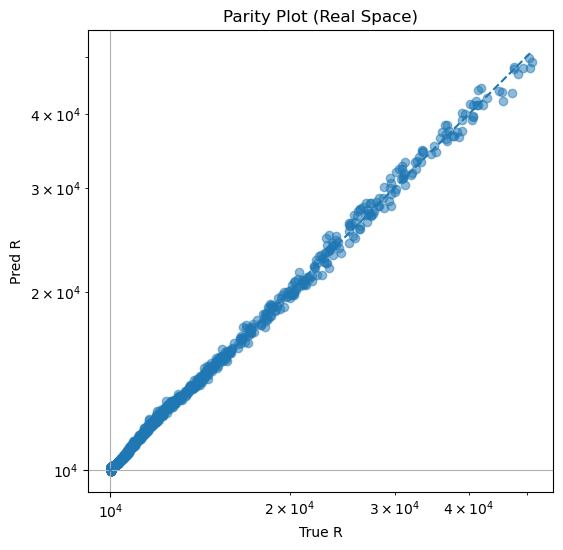

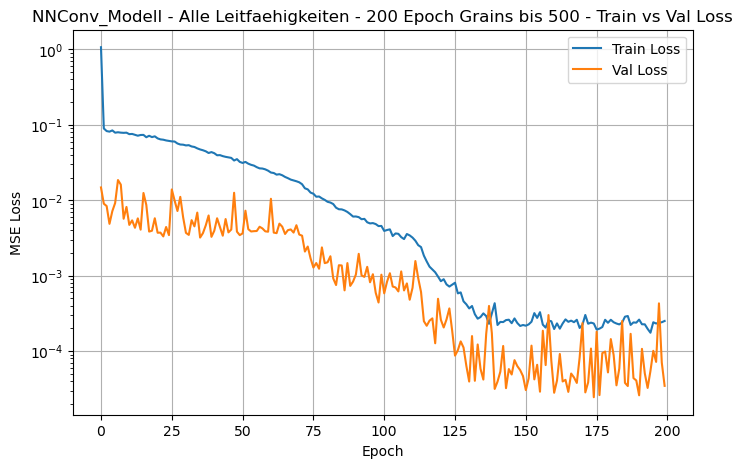

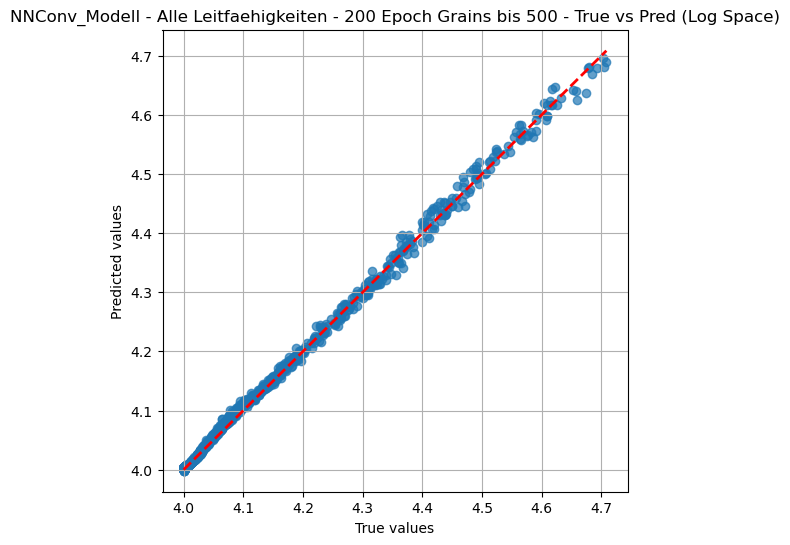

{'mae_log': 0.003889419138431549,
 'mape_log': 0.09346147999167442,
 'max_mape_log': 0.7943703792989254,
 'r2_log': 0.9981566071510315,
 'mae_real': 149.3804168701172,
 'mape_real': 0.9005230851471424,
 'max_mape_real': 8.194802701473236,
 'r2_real': 0.9970744848251343}

In [24]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import BatchNorm, GATv2Conv, global_mean_pool

EXP_NAME = "exp_model_u_nach_conv_200_epochen"
PLOT_TITLE_PREFIX = "NNConv_Modell - Alle Leitfaehigkeiten - 200 Epoch Grains bis 500"

required = [
    "ExperimentConfig",
    "GrainGNN",
    "build_dataset",
    "build_loaders",
    "analyze_model_performance",
    "predict_on_loader",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        "Diese Definitionen fehlen im Kernel: "
        + ", ".join(missing)
        + ".\nBitte zuerst die Setup-/Definitionszellen oben ausfuehren."
    )

exp_dir = os.path.join("./exps", EXP_NAME)
cfg_path = os.path.join(exp_dir, "config.json")
model_path = os.path.join(exp_dir, "best_model.pth")
history_path = os.path.join(exp_dir, "training_history.csv")

if not os.path.exists(cfg_path):
    raise FileNotFoundError(f"config.json nicht gefunden: {cfg_path}")
if not os.path.exists(model_path):
    raise FileNotFoundError(f"best_model.pth nicht gefunden: {model_path}")

with open(cfg_path, "r") as f:
    cfg_loaded = ExperimentConfig(**json.load(f))

# `weights_only=True` reduziert Pickle-Risiken in neueren Torch-Versionen.
try:
    state_dict = torch.load(model_path, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(model_path, map_location=device)


class GrainGNN_GATv2(nn.Module):
    def __init__(self, node_features=4, edge_features=2, h_fea_len=128):
        super().__init__()
        self.conv1 = GATv2Conv(node_features, 64, edge_dim=edge_features)
        self.bn1 = BatchNorm(64)
        self.conv2 = GATv2Conv(64, 64, edge_dim=edge_features)
        self.bn2 = BatchNorm(64)
        self.fc = nn.Sequential(
            nn.Linear(64 + 1, h_fea_len),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(h_fea_len, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = data.x, data.edge_index, data.edge_attr, data.batch, data.u
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x_pool = global_mean_pool(x, batch)
        if u.dim() == 1:
            u = u.view(-1, 1)
        combined = torch.cat([x_pool, u], dim=1)
        return self.fc(combined)


def detect_architecture(sd: dict) -> str:
    keys = set(sd.keys())
    if any(k.startswith("conv1.nn.") for k in keys):
        return "nnconv"
    if any(k.startswith("conv1.att") or k.startswith("conv1.lin_l") for k in keys):
        return "gatv2"
    return "unknown"


arch = detect_architecture(state_dict)
node_features = getattr(cfg_loaded, "node_features", 4)
hidden_dim = getattr(cfg_loaded, "hidden_dim", 128)
edge_features = getattr(cfg_loaded, "edge_features", 2)

if arch == "nnconv":
    loaded_model = GrainGNN(
        node_features=node_features,
        edge_features=edge_features,
        h_fea_len=hidden_dim,
    ).to(device)
elif arch == "gatv2":
    loaded_model = GrainGNN_GATv2(
        node_features=node_features,
        edge_features=edge_features,
        h_fea_len=hidden_dim,
    ).to(device)
else:
    raise RuntimeError(
        "Unbekannte Checkpoint-Architektur. Bitte Modellklasse manuell setzen."
    )

loaded_model.load_state_dict(state_dict)
loaded_model.eval()
print(f"Checkpoint geladen mit Architektur: {arch.upper()}")

if "test_loader" not in globals() or test_loader is None:
    dataset = build_dataset(cfg_loaded)
    _, _, test_loader = build_loaders(dataset, cfg_loaded)

# Trainingshistorie laden (falls vorhanden), damit Train/Val-Loss geplottet werden kann.
history_loaded = None
if os.path.exists(history_path):
    history_df = pd.read_csv(history_path)
    if {"train", "val"}.issubset(history_df.columns):
        history_loaded = {
            "train": history_df["train"].tolist(),
            "val": history_df["val"].tolist(),
        }

metrics_test = analyze_model_performance(
    loaded_model,
    test_loader,
    history=history_loaded,
    device=device,
)

# Eigener Loss-Plot mit deinem Titel.
if history_loaded is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(history_loaded["train"], label="Train Loss")
    plt.plot(history_loaded["val"], label="Val Loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"{PLOT_TITLE_PREFIX} - Train vs Val Loss")
    plt.legend()
    plt.grid()
    plt.show()

# Eigener Parity-Plot (Log) mit deinem Titel.
true_log, pred_log = predict_on_loader(loaded_model, test_loader, device)
plot_true_vs_pred(true_log, pred_log, title=f"{PLOT_TITLE_PREFIX} - True vs Pred (Log Space)")

metrics_test